# Trees and Forests



## Training a Decision Tree Classifier

### Load Data From CSV File

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
from sklearn import preprocessing
%matplotlib inline

In [2]:
df = pd.read_csv('teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


### Data Visualization and Analysis


In [3]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

### Feature set

Lets define feature sets, X:

In [4]:
df.columns

Index(['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside', 'custcat'],
      dtype='object')

To use scikit-learn library, we have to convert the Pandas data frame to a Numpy array:

In [5]:
X = df[['region', 'tenure','age', 'marital', 'address', 'income', 'ed', 'employ','retire', 'gender', 'reside']] .values  #.astype(float)
X[0:5]


array([[  2.,  13.,  44.,   1.,   9.,  64.,   4.,   5.,   0.,   0.,   2.],
       [  3.,  11.,  33.,   1.,   7., 136.,   5.,   5.,   0.,   0.,   6.],
       [  3.,  68.,  52.,   1.,  24., 116.,   1.,  29.,   0.,   1.,   2.],
       [  2.,  33.,  33.,   0.,  12.,  33.,   2.,   0.,   0.,   1.,   1.],
       [  2.,  23.,  30.,   1.,   9.,  30.,   1.,   2.,   0.,   0.,   4.]])

In [6]:
y = df['custcat'].values
y[0:5]


array([1, 4, 3, 1, 3])

### Train Test Split
Out of Sample Accuracy is the percentage of correct predictions that the model makes on data that that the model has NOT been trained on. Doing a train and test on the same dataset will most likely have low out-of-sample accuracy, due to the likelihood of being over-fit.

It is important that our models have a high, out-of-sample accuracy, because the purpose of any model, of course, is to make correct predictions on unknown data. So how can we improve out-of-sample accuracy? One way is to use an evaluation approach called Train/Test Split. Train/Test Split involves splitting the dataset into training and testing sets respectively, which are mutually exclusive. After which, you train with the training set and test with the testing set.

This will provide a more accurate evaluation on out-of-sample accuracy because the testing dataset is not part of the dataset that have been used to train the data. It is more realistic for real world problems.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (800, 11) (800,)
Test set: (200, 11) (200,)


In [8]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix


decisiontree = DecisionTreeClassifier(random_state=0)
model = decisiontree.fit(X_train, y_train)

target_predicted=model.predict(X_test)
print("Accuracy", model.score(X_test, y_test))

matrix = confusion_matrix(y_test, target_predicted)
print("Class Confusion Matrix\n", matrix)



Accuracy 0.395
Class Confusion Matrix
 [[30  6 10  5]
 [ 7 19  8 10]
 [15 14 17  8]
 [18  9 11 13]]


### Discussion
Decision tree learners attempt to find a decision rule that produces the greatest decrease in impurity at a node. While there are a number of measurements of impurity, by default `DecisionTreeClassifier` uses Gini impurity:
$$
G(t) = 1 - \sum_{i=1}^c{p_i^2}
$$
where G(t) is the Gini impurity at node t and $p_i$ is the proportion of observations of class c at node t.

This process of finding the decision rules that create splits to increase impurity is repeated recursively untill all leaf nodes are pure (i.e. contain only one class) or some abritary cut-off is reached

We can change the `criterion` parameter to use a different impurity measurement

In [9]:
# create decision tree classifier using entropy
decisiontree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0)

model_entropy = decisiontree_entropy.fit(X_train, y_train)

target_predicted=model_entropy.predict(X_test)
print("Accuracy", model_entropy.score(X_test, y_test))

matrix = confusion_matrix(y_test, target_predicted)
print("Class Confusion Matrix\n", matrix)



Accuracy 0.325
Class Confusion Matrix
 [[22  9 12  8]
 [13 11  8 12]
 [15 13 18  8]
 [10 14 13 14]]


In [10]:
## Write your own code for decision tree by using Information Gain 
## Don't use ready code 

def entropy(y):
    unique_labels, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs))

class Node:
    def __init__(self, is_leaf=False, label=None, feature=None, threshold=None, left=None, right=None):
        self.is_leaf = is_leaf      
        self.label = label          
        self.feature = feature      
        self.threshold = threshold  
        self.left = left            
        self.right = right          

class CustomDecisionTree:
    def __init__(self):
        self.root = None

    def fit(self, X, y):
        self.root = self.build_tree(X, y)
    
    def build_tree(self, X, y):
        if len(np.unique(y)) == 1:
            return Node(is_leaf=True, label=y[0])

        best_feature, best_threshold, best_gain = self.find_best_split(X, y)

        if best_gain == 0:
            most_common = np.bincount(y).argmax()
            return Node(is_leaf=True, label=most_common)

        left_indices = X[:, best_feature] <= best_threshold
        right_indices = X[:, best_feature] > best_threshold
        
        left_child = self.build_tree(X[left_indices], y[left_indices])
        right_child = self.build_tree(X[right_indices], y[right_indices])

        return Node(is_leaf=False, feature=best_feature, threshold=best_threshold, 
                    left=left_child, right=right_child)
    
    def find_best_split(self, X, y):
        best_gain = 0
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]

        for feature in range(n_features):
            thresholds = self.get_thresholds(X[:, feature])
            for threshold in thresholds:
                gain = self.information_gain(X, y, feature, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain
    
    def get_thresholds(self, feature_values):
        # averages non-repeating values
        unique_vals = np.unique(feature_values)
        return (unique_vals[:-1] + unique_vals[1:]) / 2
    
    def information_gain(self, X, y, feature, threshold):
        parent_entropy = entropy(y)
        left_indices = X[:, feature] <= threshold
        right_indices = X[:, feature] > threshold

        n_left = np.sum(left_indices)
        n_right = np.sum(right_indices)
        if n_left == 0 or n_right == 0:
            return 0

        # Weighted entropy after split
        n = len(y)
        left_entropy = entropy(y[left_indices])
        right_entropy = entropy(y[right_indices])
        child_entropy = (n_left / n) * left_entropy + (n_right / n) * right_entropy

        return parent_entropy - child_entropy
    
    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])
    
    def predict_single(self, x):
        node = self.root
        while not node.is_leaf:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.label
    
custom_tree = CustomDecisionTree()
custom_tree.fit(X_train, y_train)

y_pred = custom_tree.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Accuracy", accuracy)

matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix\n", matrix)

Accuracy 0.31
Confusion Matrix
 [[22  8 13  8]
 [16  9  6 13]
 [14 15 18  7]
 [13 13 12 13]]




##  Visualizing a Decision Tree Model

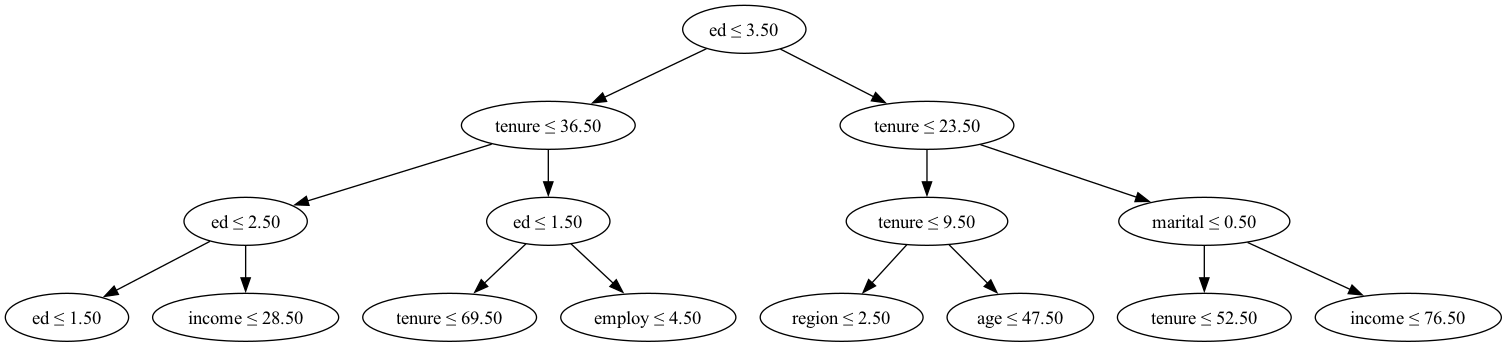

In [11]:
import pydotplus
from sklearn.tree import DecisionTreeClassifier
from IPython.display import Image
from sklearn import tree


feature_names = ['region','tenure','age','marital','address',
                 'income','ed','employ','retire','gender','reside']

def visualize_tree(node, depth=0, parent_id=None, graph=None, n_rows=4):
    if graph is None:
        graph = pydotplus.Dot(graph_type='digraph')
    
    if depth >= n_rows or node.is_leaf:
        return graph

    node_id = str(id(node))
    label = f"{feature_names[node.feature]} ≤ {node.threshold:.2f}"
    graph.add_node(pydotplus.Node(node_id, label=label))
    if parent_id:
        graph.add_edge(pydotplus.Edge(parent_id, node_id))

    visualize_tree(node.left,  depth+1, node_id, graph, n_rows)
    visualize_tree(node.right, depth+1, node_id, graph, n_rows)
    return graph


graph = visualize_tree(custom_tree.root, n_rows=4)
Image(graph.create_png())

